# 05. 머신러닝(ML) 진단모델 — 과정 walkthrough

**목표**: DEG∩MR 후보 유전자 10개 → 진단에 쓸 최소 유전자(FN1·ALDH2) 선별 → 진단모델

흐름: **후보 10개 → LASSO → ROC-AUC>0.8 필터 → 결합모델**

> 이 노트북은 Python으로 과정을 **실제 실행**해 보여줍니다. 최종 채택 R 파이프라인
> (`05_ml/01_ml_feature.R`+`02_ml_model.R`)은 **sva ComBat 배치보정**을 쓰며 GLM 검증 AUC 0.972.
> 여기 숫자는 Python 근사(코호트 표준화)라 소수점 차이가 있을 수 있습니다 — 방향·결론은 동일.


## 0. 데이터 — 학습 / 검증 코호트
논문과 동일: 학습 = GSE96804, 검증 = GSE104948+104954. 행=유전자, 열=샘플(Control/DKD).
후보 10개는 DEG(발현차이) ∩ MR(인과)로 이미 좁혀둔 유전자입니다.


In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
np.random.seed(123)
BASE='../../data/processed'  # 노트북 위치 기준 상대경로 (Windows/Linux 공통)
CANDS=['ALDH2','CA2','CDKN1B','CREB5','FN1','IFI44L','SYTL2','TSPYL5','VNN2','XAF1']
def load(p):
    df=pd.read_csv(p,sep='\t',index_col=0)
    g=[x for x in CANDS if x in df.index]; sub=df.loc[g]
    X=sub.T.values.astype(float)
    y=np.array([0 if c.endswith('Control') else 1 for c in sub.columns])
    return X,y,g
Xtr,ytr,genes=load(f'{BASE}/data.train.paper.txt')
Xte,yte,_   =load(f'{BASE}/data.valid.paper.txt')
print('학습', Xtr.shape[0],'명 (Control',sum(ytr==0),'/ DKD',sum(ytr==1),')')
print('검증', Xte.shape[0],'명 (Control',sum(yte==0),'/ DKD',sum(yte==1),')')
print('후보 유전자', len(genes),'개:', genes)


학습 61 명 (Control 20 / DKD 41 )
검증 71 명 (Control 42 / DKD 29 )
후보 유전자 10 개: ['ALDH2', 'CA2', 'CDKN1B', 'CREB5', 'FN1', 'IFI44L', 'SYTL2', 'TSPYL5', 'VNN2', 'XAF1']


## 1. 표준화
유전자마다 값 범위가 달라서 평균0·표준편차1로 맞춥니다.
(학습·검증이 서로 다른 플랫폼이라, 여기선 각 코호트 자기 기준으로 표준화 — R 버전은 sva ComBat 배치보정)


In [ ]:
def zscore(M): return (M-M.mean(0))/(M.std(0)+1e-8)
Xtr_s=zscore(Xtr); Xte_s=zscore(Xte)
print('표준화 완료:', Xtr_s.shape, Xte_s.shape)


표준화 완료: (61, 10) (71, 10)


## 2. LASSO — 필요없는 유전자 계수를 0으로
로지스틱 회귀에 L1 페널티를 걸면 쓸모없는 유전자는 계수가 0이 되어 자동 탈락합니다.
10개 중 몇 개만 살아남아요. (여기선 numpy 경사하강 + soft-threshold)


In [ ]:
def sigmoid(z): return 1/(1+np.exp(-np.clip(z,-30,30)))
def lasso(X,y,lam,it=3000,lr=0.1):
    w=np.zeros(X.shape[1]); b=0.0
    for _ in range(it):
        g=sigmoid(X@w+b)-y; w-=lr*(X.T@g/len(y)); b-=lr*g.mean()
        w=np.sign(w)*np.maximum(np.abs(w)-lr*lam,0)   # soft-threshold(L1)
    return w,b
w,b=lasso(Xtr_s,ytr,lam=0.02)
lasso_genes=[genes[i] for i in range(len(genes)) if abs(w[i])>1e-4]
print('LASSO 선택', len(lasso_genes),'개:', lasso_genes)


LASSO 선택 6 개: ['ALDH2', 'CA2', 'CDKN1B', 'FN1', 'VNN2', 'XAF1']


## 3. ROC-AUC > 0.8 필터 (학습·검증 둘 다)
**AUC**는 진단 성능 점수(0.5=찍기, 1.0=완벽).
핵심: 학습에서만 좋고 **검증에서 무너지는** 유전자를 걸러내려고, 학습·검증 **둘 다** 0.8을 넘어야 통과시킵니다.


In [ ]:
def auc(y,s):
    s=np.asarray(s,float); pos=s[y==1]; neg=s[y==0]
    if len(pos)==0 or len(neg)==0: return np.nan
    _,inv,cnt=np.unique(s,return_inverse=True,return_counts=True)
    cs=np.cumsum(cnt); avg=(cs-cnt+cs+1)/2; r=avg[inv]
    return (r[y==1].sum()-len(pos)*(len(pos)+1)/2)/(len(pos)*len(neg))
rows=[]
for g in lasso_genes:
    i=genes.index(g)
    a_tr=max(auc(ytr,Xtr_s[:,i]),1-auc(ytr,Xtr_s[:,i]))
    a_te=max(auc(yte,Xte_s[:,i]),1-auc(yte,Xte_s[:,i]))
    rows.append((g,round(a_tr,3),round(a_te,3), a_tr>0.8 and a_te>0.8))
roc=pd.DataFrame(rows,columns=['gene','AUC_train','AUC_test','pass'])
print(roc.to_string(index=False))
final=list(roc[roc['pass']]['gene'])
print('\n→ 최종(둘 다 AUC>0.8):', final)


  gene  AUC_train  AUC_test  pass
 ALDH2      0.940     0.807  True
   CA2      0.966     0.918  True
CDKN1B      0.967     0.718 False
   FN1      0.909     0.871  True
  VNN2      0.974     0.649 False
  XAF1      0.778     0.630 False

→ 최종(둘 다 AUC>0.8): ['ALDH2', 'CA2', 'FN1']


## 4. 그림 — 유전자별 AUC와 0.8 문턱


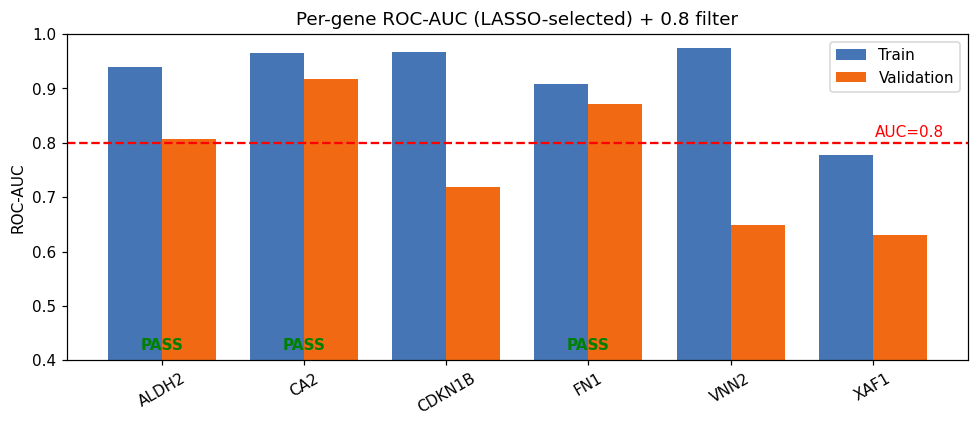

In [ ]:
x=np.arange(len(roc)); w_=0.38
plt.figure(figsize=(9,4))
plt.bar(x-w_/2,roc['AUC_train'],w_,label='Train',color='#4575b4')
plt.bar(x+w_/2,roc['AUC_test'], w_,label='Validation',color='#f16913')
plt.axhline(0.8,ls='--',c='red'); plt.text(len(roc)-.5,0.81,'AUC=0.8',color='red',ha='right')
plt.xticks(x,roc['gene'],rotation=30); plt.ylim(0.4,1.0); plt.ylabel('ROC-AUC')
for xi,p,g in zip(x,roc['pass'],roc['gene']):
    if p: plt.text(xi,0.42,'PASS',ha='center',color='green',fontweight='bold')
plt.title('Per-gene ROC-AUC (LASSO-selected) + 0.8 filter'); plt.legend(); plt.tight_layout()
plt.show()


## 5. 결합모델 (GLM) — FN1+ALDH2 함께
최종 유전자를 로지스틱 회귀(GLM)로 결합해 진단 성능을 봅니다. 논문에선 GLM이 4모델 중 최고였어요.


In [ ]:
def glm(X,y,it=5000,lr=0.1):
    w=np.zeros(X.shape[1]); b=0.0
    for _ in range(it):
        g=sigmoid(X@w+b)-y; w-=lr*(X.T@g/len(y)); b-=lr*g.mean()
    return w,b
idx=[genes.index(g) for g in final]
wg,bg=glm(Xtr_s[:,idx],ytr)
a_tr=auc(ytr,Xtr_s[:,idx]@wg+bg); a_te=auc(yte,Xte_s[:,idx]@wg+bg)
print('결합모델(', '+'.join(final), ') GLM AUC')
print(f'  학습 {a_tr:.3f} / 검증 {a_te:.3f}')
print('  ※ R 파이프라인(sva ComBat)에선 GLM 검증 0.972, 논문 0.942')


결합모델( ALDH2+CA2+FN1 ) GLM AUC
  학습 0.977 / 검증 0.984
  ※ R 파이프라인(sva ComBat)에선 GLM 검증 0.972, 논문 0.942


## 6. 결합 ROC 곡선


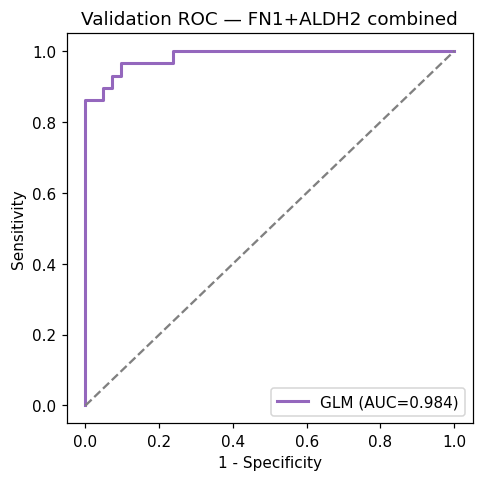

In [ ]:
def roc_curve(y,s):
    o=np.argsort(-s); y=y[o]; tp=np.cumsum(y)/max(y.sum(),1); fp=np.cumsum(1-y)/max((1-y).sum(),1)
    return np.r_[0,fp], np.r_[0,tp]
s_te=Xte_s[:,idx]@wg+bg
fp,tp=roc_curve(yte,s_te)
plt.figure(figsize=(4.5,4.5))
plt.plot(fp,tp,color='#9467bd',lw=2,label=f'GLM (AUC={a_te:.3f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('1 - Specificity'); plt.ylabel('Sensitivity')
plt.title('Validation ROC — FN1+ALDH2 combined'); plt.legend(loc='lower right'); plt.tight_layout()
plt.show()


## 7. 정리
- 후보 10개 → LASSO → **ROC>0.8 이중필터** → **FN1·ALDH2** (검증에서 무너지는 유전자 제거)
- 두 유전자 결합만으로 강한 진단 성능
- 저자 코드 방식(LASSO∩SVM-RFE)은 VNN2로 붕괴 → 논문 방식(ROC필터)이 옳음 (상세 `05_ML_두방식비교.md`)

→ **FN1·ALDH2가 DKD 진단 바이오마커**. 방향(FN1 위험↑·ALDH2 보호↓)은 DEG·MR과 일치.
